# Аналитика

## Библиотеки и полезное

In [28]:
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from yaml import warnings
import warnings
import os
import cv2

mpl.rcParams.update(mpl.rcParamsDefault)
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_context("notebook", font_scale=1.2)
sns.set_style("whitegrid")

## Загрузка данных

In [29]:
output_frames_dir = r'C:\Users\Aleksandr\Downloads\fsva-test-main\fsva-test\output\frames'
cropped_frame_files = sorted(os.listdir(output_frames_dir))

box_sizes_df = pd.read_csv(r'C:\Users\Aleksandr\Downloads\fsva-test-main\fsva-test\output\box_sizes.csv')
widths = box_sizes_df['width'].values
heights = box_sizes_df['height'].values


In [30]:
print('Получилось записей', len(cropped_frame_files))

Получилось записей 727


## Просмотр

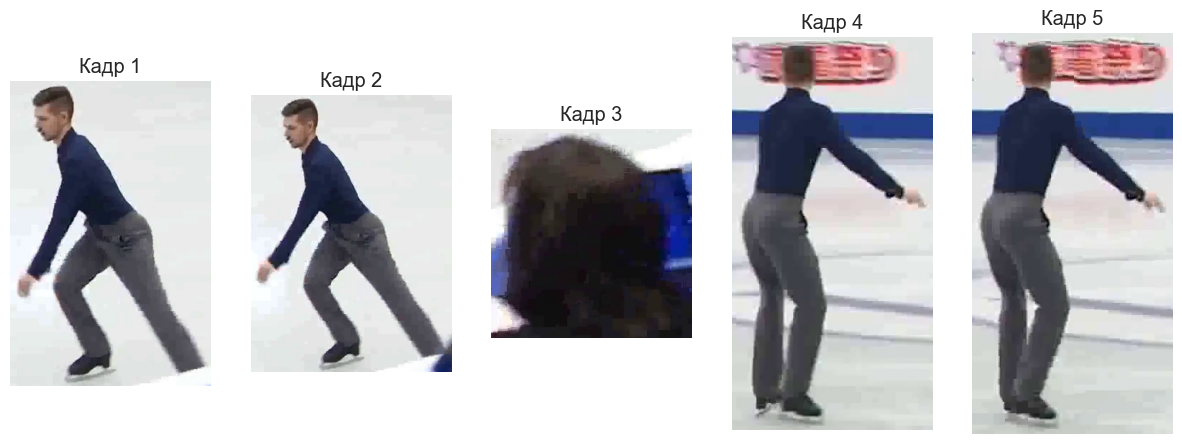

In [31]:
plt.figure(figsize=(15, 10))
for i in range(min(5, len(cropped_frame_files))):  # Отображаем первые 5 кадров
    frame = cv2.imread(os.path.join(output_frames_dir, cropped_frame_files[i]))
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'Кадр {i + 1}')
plt.show()

**Теперь понятно, что YOLO как то надо донастраивать, примерно так (python train.py --img 640 --batch 16 --epochs 50 --data your_data.yaml --weights yolov5s.pt)**

## Построение графиков изменения размера бокса

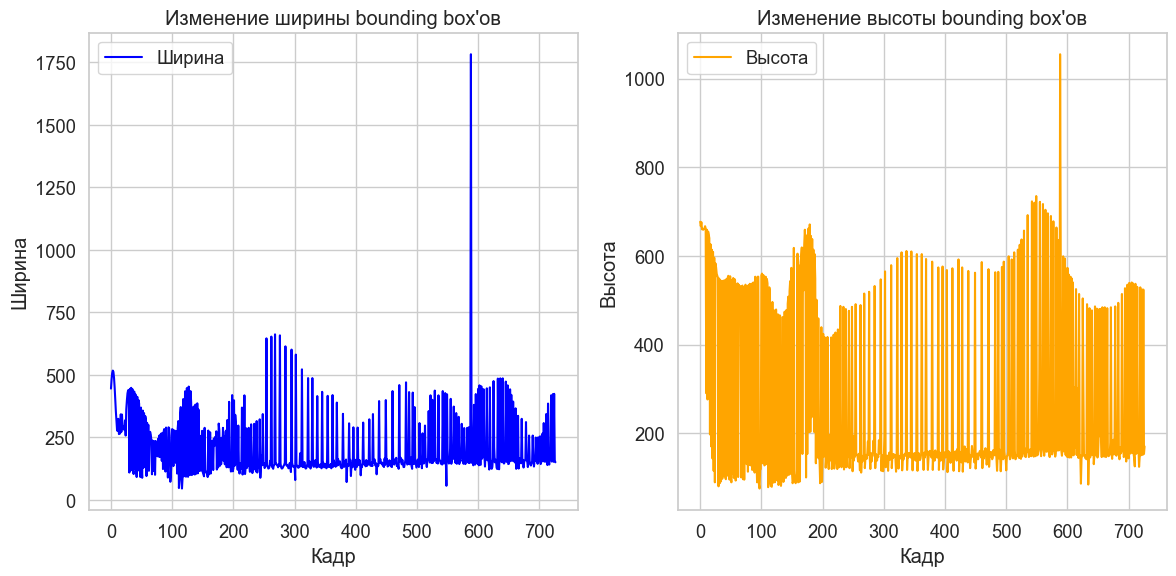

In [32]:
# Предполагается, что box_sizes - это список кортежей (ширина, высота)
plt.figure(figsize=(12, 6))

# График изменения ширины
plt.subplot(1, 2, 1)
plt.plot(widths, label='Ширина', color='blue')
plt.title('Изменение ширины bounding box\'ов')
plt.xlabel('Кадр')
plt.ylabel('Ширина')
plt.legend()

# График изменения высоты
plt.subplot(1, 2, 2)
plt.plot(heights, label='Высота', color='orange')
plt.title('Изменение высоты bounding box\'ов')
plt.xlabel('Кадр')
plt.ylabel('Высота')
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
# Рассчет среднего и стандартного отклонения
avg_width = np.mean(widths)
std_width = np.std(widths)
avg_height = np.mean(heights)
std_height = np.std(heights)

print(f"Средняя ширина: {avg_width:.2f}, Стандартное отклонение ширины: {std_width:.2f}")
print(f"Средняя высота: {avg_height:.2f}, Стандартное отклонение высоты: {std_height:.2f}")

Средняя ширина: 204.51, Стандартное отклонение ширины: 125.58
Средняя высота: 262.05, Стандартное отклонение высоты: 193.63


## Выводы о стабильности модели

- Средняя ширина и высота bounding box'ов показывают, насколько не стабильно модель детектирует фигуру спортсмена.
- Низкое стандартное отклонение указывает на  стабильность детекции, в то время как высокое стандартное отклонение может указывать на проблемы с детекцией в некоторых кадрах.